# SHAP Explainability + Disputed-Text Inference — Shakespeare Authorship Verification

1. Runs the trained best model on the disputed texts (Henry VI Parts I/II/III, Spanish Tragedy,
   Double Falsehood) per-chunk probabilities, aggregated per play
2. Explains those predictions with SHAP — per-chunk waterfalls, plus an aggregate summary of
   which features push toward "Shakespeare" vs "not Shakespeare" across the disputed set




In [ ]:
!pip install shap -q

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import re

In [ ]:
BASE_PATH = "/content/drive/MyDrive/shakespeare_project/"

# Load the data assets
with open(BASE_PATH + "features.pkl", "rb") as f:
    feat_data = pickle.load(f)

with open(BASE_PATH + "modeling_results.pkl", "rb") as f:
    model_data = pickle.load(f)

X_train = feat_data["X_train"]
y_train = feat_data["y_train"]
X_disputed = feat_data["X_disputed"]
disputed_df = feat_data["disputed_df"].copy()
function_words = feat_data["function_words"]
char_vectorizer = feat_data["char_vectorizer"]

fitted_models = model_data["fitted_models"]
best_model_name = model_data["best_model_name"]
scaler = model_data["scaler"]
best_model = fitted_models[best_model_name]

is_not_titus = disputed_df["play"] != "titus_andronicus.txt"
X_disputed = X_disputed[is_not_titus.values]
disputed_df = disputed_df[is_not_titus].reset_index(drop=True)

NEEDS_SCALING = {
    "Logistic Regression": True,
    "SVM (linear)": True,
    "Random Forest": False,
    "Gradient Boosting": False,
}
needs_scaling = NEEDS_SCALING[best_model_name]

marker_words = feat_data["marker_words"]
feature_names = list(function_words) + list(char_vectorizer.get_feature_names_out()) + list(marker_words)

X_train_input = scaler.transform(X_train) if needs_scaling else X_train
X_disputed_input = scaler.transform(X_disputed) if needs_scaling else X_disputed

print(f"Best model: {best_model_name}  (needs_scaling={needs_scaling})")
print(f"X_disputed_input: {X_disputed_input.shape}   n_features: {len(feature_names)}")

print("\nInitializing SHAP Linear Explainer...")
background_summary = shap.sample(X_train_input, 100, random_state=42)
explainer = shap.LinearExplainer(best_model, background_summary)

print("Calculating analytic SHAP values for the 106 clean disputed chunks...")
shap_values = explainer(X_disputed_input)
shap_values.feature_names = feature_names

print("\nSHAP initialization complete!")
print(f"SHAP Values Matrix Shape: {shap_values.shape}")

Best model: Logistic Regression  (needs_scaling=True)
X_disputed_input: (106, 2182)   n_features: 2182

Initializing SHAP Linear Explainer...
Calculating analytic SHAP values for the 106 clean disputed chunks...

SHAP initialization complete!
SHAP Values Matrix Shape: (106, 2182)


## Disputed inference


In [ ]:
disputed_df = disputed_df.reset_index(drop=True)
disputed_df["shakespeare_probability"] = best_model.predict_proba(X_disputed_input)[:, 1]

per_play_summary = (
    disputed_df.groupby("author")["shakespeare_probability"]
    .agg(["mean", "std", "min", "max", "count"])
    .sort_values("mean", ascending=False)
)
print(f"Per-chunk predictions using: {best_model_name}\n")
print(per_play_summary)


Per-chunk predictions using: Logistic Regression

                      mean       std       min       max  count
author                                                         
henry_vi_part3    0.842198  0.311265  0.014050  0.999875     24
henry_vi_part2    0.802072  0.297035  0.002253  0.999987     24
double_falsehood  0.639265  0.409036  0.013098  0.997430     15
henry_vi_part1    0.576631  0.339448  0.007793  0.999950     21
spanish_tragedy   0.109066  0.225581  0.000008  0.808746     22


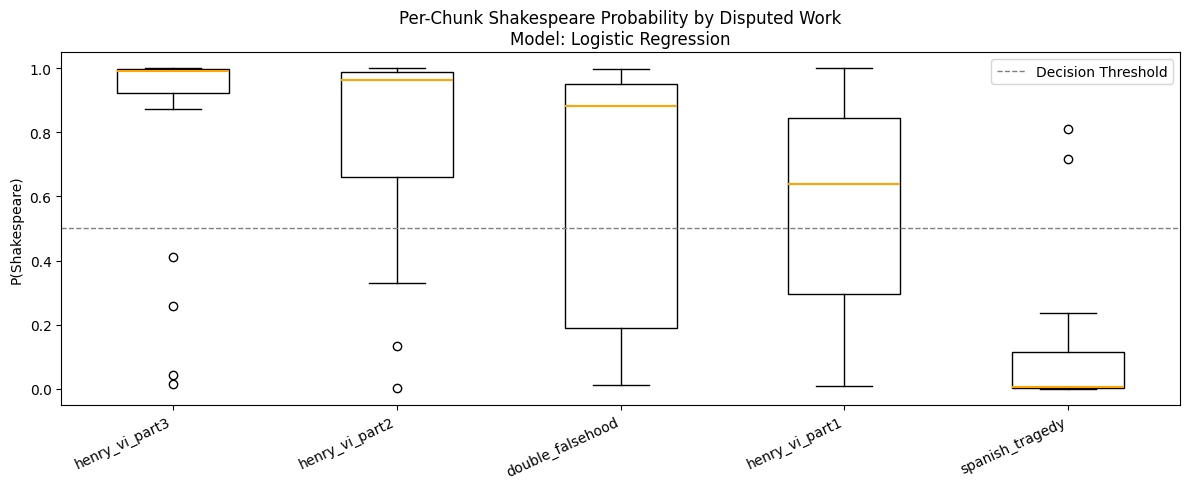

In [ ]:
order = per_play_summary.index.tolist()
data_by_play = [disputed_df.loc[disputed_df["author"] == a, "shakespeare_probability"].values for a in order]

plt.figure(figsize=(12, 5))
plt.boxplot(data_by_play, vert=True, widths=0.5, patch_artist=True,
            boxprops=dict(facecolor="white", color="black"),
            medianprops=dict(color="orange", linewidth=1.5))

plt.xticks(ticks=range(1, len(order) + 1), labels=order, rotation=25, ha="right")

plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Decision Threshold")
plt.ylabel("P(Shakespeare)")
plt.title(f"Per-Chunk Shakespeare Probability by Disputed Work\nModel: {best_model_name}")
plt.legend()

plt.tight_layout()
plt.show()

## Build the explainer


In [ ]:
representative_indices = []
for author in order:
    sub = disputed_df[disputed_df["author"] == author]
    typical_label = (sub["shakespeare_probability"] - sub["shakespeare_probability"].mean()).abs().idxmin()
    representative_indices.append(disputed_df.index.get_loc(typical_label))
X_representative = X_disputed_input[representative_indices]
background_summary = shap.sample(X_train_input, 30, random_state=42)
def predict_prob_class1(x):
    return best_model.predict_proba(x)[:, 1]

explainer = shap.Explainer(predict_prob_class1, background_summary, max_evals=4500)
shap_values_rep = explainer(X_representative)
shap_values_rep.feature_names = feature_names

## Explain predictions per chunk

In [ ]:
background = shap.sample(X_train_input, 100, random_state=42)
explainer = shap.Explainer(best_model, background, feature_names=feature_names)

shap_values_disputed = explainer(X_disputed_input)
print(shap_values_disputed.values.shape)

(106, 2182)



=== HENRY_VI_PART3 (Chunk 61) — P(Shakespeare) = 0.873 ===


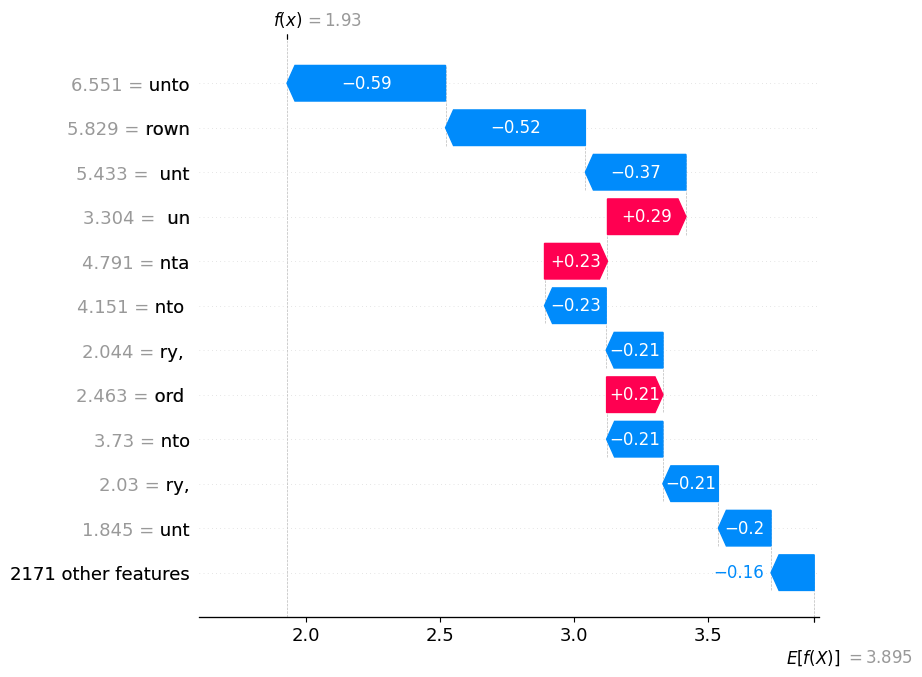


=== HENRY_VI_PART2 (Chunk 59) — P(Shakespeare) = 0.848 ===


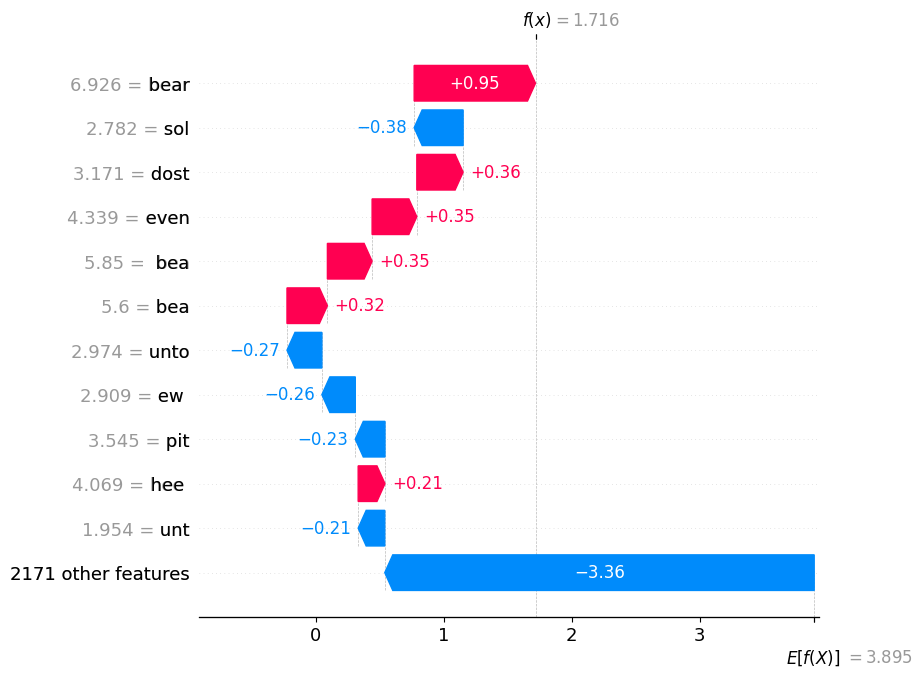


=== DOUBLE_FALSEHOOD (Chunk 7) — P(Shakespeare) = 0.739 ===


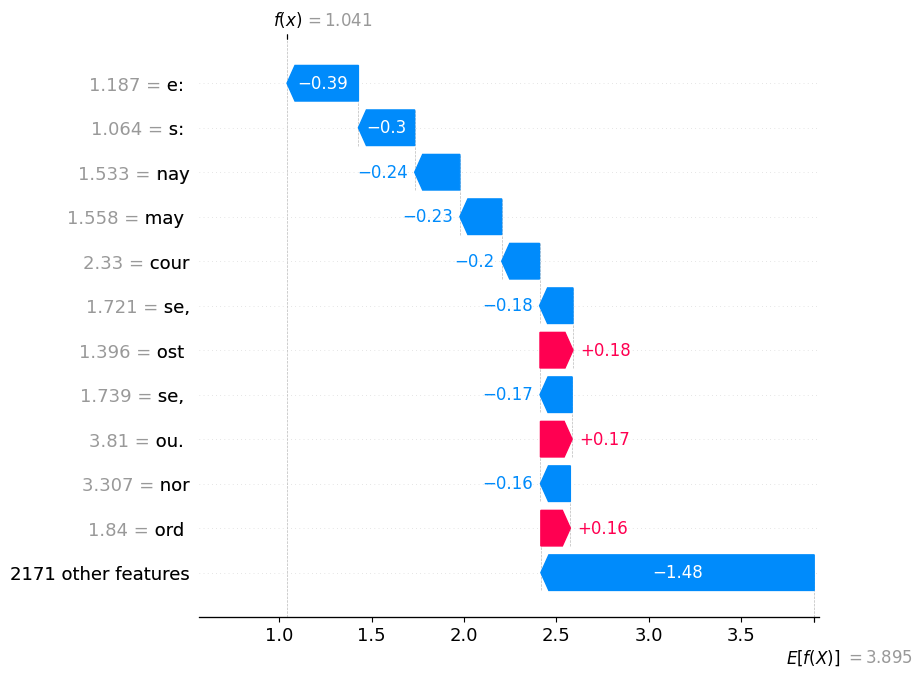


=== HENRY_VI_PART1 (Chunk 33) — P(Shakespeare) = 0.566 ===


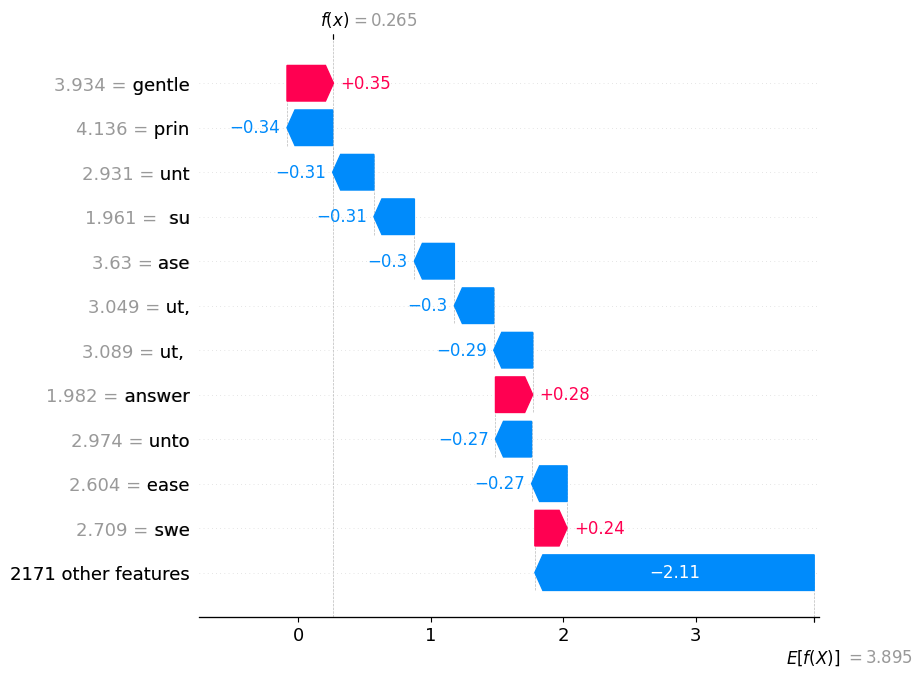


=== SPANISH_TRAGEDY (Chunk 104) — P(Shakespeare) = 0.143 ===


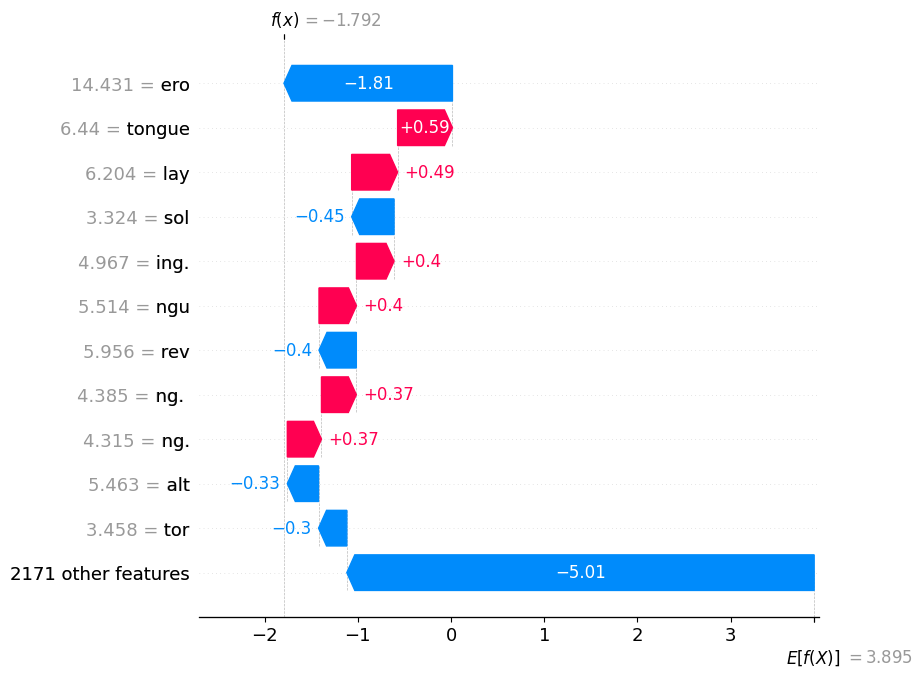

In [ ]:
for author in order:
    sub = disputed_df[disputed_df["author"] == author
    typical_label = (sub["shakespeare_probability"] - sub["shakespeare_probability"].mean()).abs().idxmin()
    typical_pos_idx = disputed_df.index.get_loc(typical_label)

    print(f"\n=== {author.upper()} (Chunk {typical_pos_idx}) — P(Shakespeare) = {disputed_df.loc[typical_label, 'shakespeare_probability']:.3f} ===")

    shap.plots.waterfall(shap_values_disputed[typical_pos_idx], max_display=12)

/tmp/ipykernel_1029/215694422.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_disputed.values,


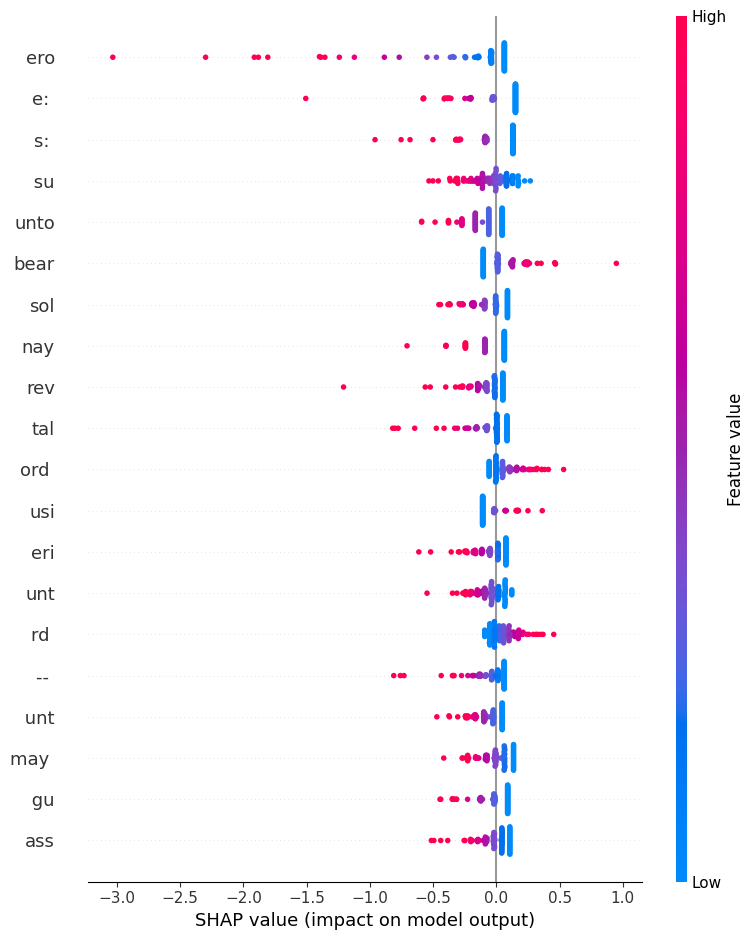

In [ ]:
shap.summary_plot(shap_values_disputed.values,
                  X_disputed_input,
                  feature_names=feature_names,
                  max_display=20,
                  show=True)

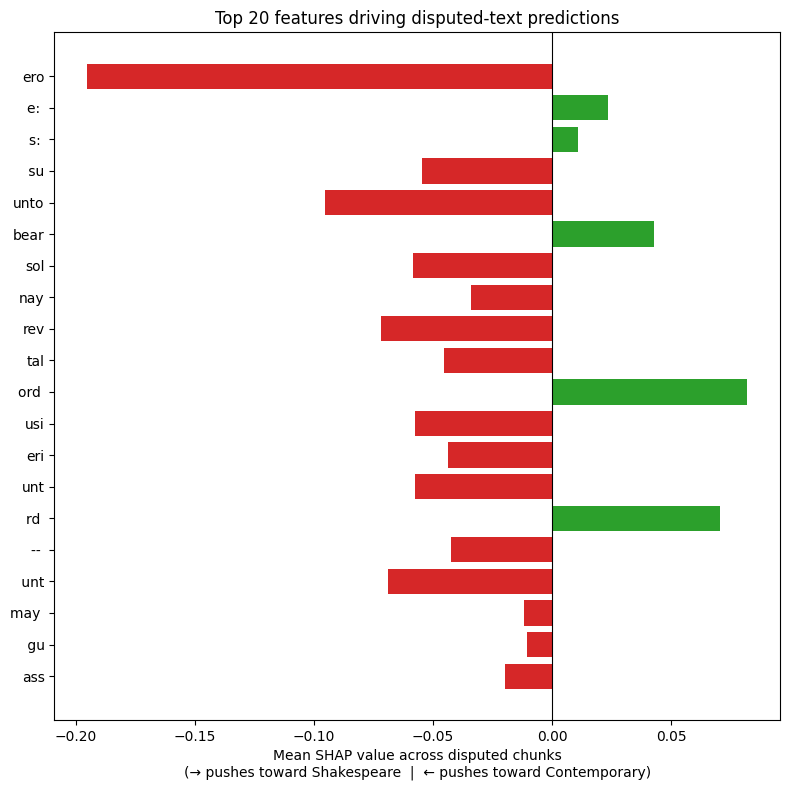

In [ ]:
mean_shap = shap_values_disputed.values.mean(axis=0)
mean_abs_shap = np.abs(shap_values_disputed.values).mean(axis=0)

top_idx = np.argsort(mean_abs_shap)[::-1][:20]
top_features = [feature_names[i] for i in top_idx]
top_values = mean_shap[top_idx]

colors = ["#2ca02c" if v > 0 else "#d62728" for v in top_values]

plt.figure(figsize=(8, 8))
plt.barh(range(len(top_features)), top_values[::-1], color=list(reversed(colors)))
plt.yticks(range(len(top_features)), list(reversed(top_features)))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mean SHAP value across disputed chunks\n(→ pushes toward Shakespeare  |  ← pushes toward Contemporary)")
plt.title("Top 20 features driving disputed-text predictions")
plt.tight_layout()
plt.show()

In [ ]:
chunked_df = pd.read_pickle(BASE_PATH + "chunked_corpus.pkl")
text_lookup = chunked_df.set_index("chunk_id")["text"]

suspect_ngrams = ["e:", "s:", "d.", "t,", "s,", "--"]

for ngram in suspect_ngrams:
    print(f"\n=== '{ngram}' ===")
    matching_ids = disputed_df.loc[disputed_df["chunk_id"].isin(text_lookup.index)]
    hits = matching_ids[text_lookup.reindex(matching_ids["chunk_id"]).str.contains(
        re.escape(ngram), regex=True, na=False).values]
    if len(hits):
        chunk_id = hits.iloc[0]["chunk_id"]
        sample_text = text_lookup[chunk_id]
        idx = sample_text.find(ngram)
        print(sample_text[max(0, idx - 40): idx + 40])
    else:
        print("(no matches found)")


=== 'e:' ===
e a husband i may weep; never, to get one: when i cry for bondage, let freedom q

=== 's:' ===
er day in a spleen against your new suits: i do now think, some fate was the tay

=== 'd.' ===
your person; your sole person. read aloud. 'please you, to let me first o'erlook

=== 't,' ===
pride, spreads me with blushes. think not, that i can flatter thee, my roderick;

=== 's,' ===
en; worthy the man, who, with my dukedoms, heirs my better glories. this praise'

=== '--' ===
r, they are for the palace of the duke. -- your father's house is too dusty. hem


In [ ]:
with open(BASE_PATH + "shap_results.pkl", "wb") as f:
    pickle.dump({
        "disputed_df": disputed_df,
        "per_play_summary": per_play_summary,
        "shap_values_disputed": shap_values_disputed.values,
        "feature_names": feature_names,
        "best_model_name": best_model_name,
    }, f)

print("Saved shap_results.pkl to", BASE_PATH)